In [0]:
storage_account_name = "amazondatalake60307052"
storage_account_key = "rbXHUr9voqcrJI5eLoNEFzc4ULCNRK1qI7Ogtmh2gQrGGkLnR9uDGTEN2txtGTxC43EZpQKwse9K+AStPfT+KA=="

spark.conf.set(
    f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
    storage_account_key
)

gold_path = "abfss://curated@amazondatalake60307052.dfs.core.windows.net/features_v1/"

df = spark.read.parquet(gold_path)
df.printSchema()



root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)



+----------+-------+----------------------------------------------------------------------------------------------------+-------------+
|      asin|overall|                                                                                          reviewText|review_length|
+----------+-------+----------------------------------------------------------------------------------------------------+-------------+
|B008MP7634|    5.0|This replacement digitizer was a great fit for my ipad2.  it was easy to install and easy to repl...|          242|
|B008MP7634|    5.0|The quality is fantastic. I replaced mine a while ago and have not had any problems. I am glad I ...|          473|
|B008MP7634|    4.0|This was the very first digitizer I had ever replaced.  It really wasn't too bad, the only issues...|         1102|
|B008MP7634|    5.0|This is a legit, iPad 2, Glass Digitizer. The product is shipped from Shenzhen China and states i...|         1377|
|B008MP7634|    1.0|Glass cracked while I was si

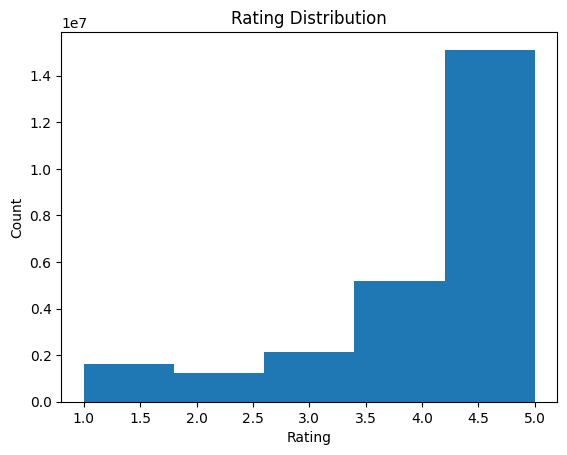

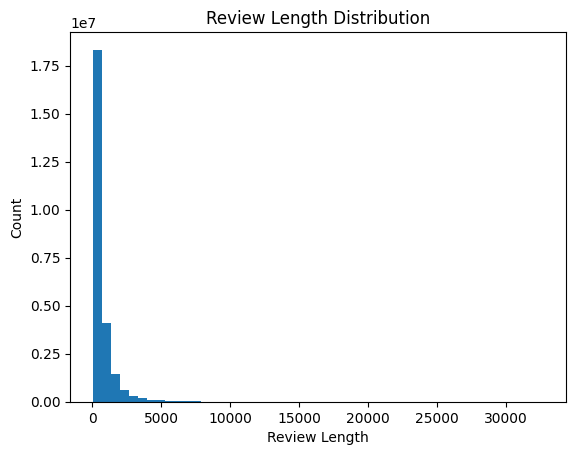

Sample size: 5061631
Train size: 3545517
Validation size: 758382
Test size: 759181


In [0]:
from pyspark.sql.functions import length, col
import matplotlib.pyplot as plt

# 1️⃣ Create review length feature
df = df.withColumn("review_length", length(col("reviewText")))

# 2️⃣ Quick display of first 5 rows
df.select("asin", "overall", "reviewText", "review_length").show(5, truncate=100)

# 3️⃣ Column count
print("Number of columns:", len(df.columns))

# 4️⃣ Rating distribution
ratings_pd = df.select("overall").toPandas()
plt.hist(ratings_pd["overall"], bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# 5️⃣ Review length distribution
length_pd = df.select("review_length").toPandas()
plt.hist(length_pd["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Review Length")
plt.ylabel("Count")
plt.show()

# 6️⃣ Optional: sample dataset for next steps (20% sample)
sample_df = df.sample(fraction=0.2, seed=42)
print("Sample size:", sample_df.count())

# 7️⃣ Train/Validation/Test split
train_df, val_df, test_df = sample_df.randomSplit([0.7, 0.15, 0.15], seed=42)
print("Train size:", train_df.count())
print("Validation size:", val_df.count())
print("Test size:", test_df.count())

The plot shows most reviews are 4–5 stars, with fewer low ratings (1–2 stars).

This matters because models trained on imbalanced ratings may overpredict high ratings.

Could require sampling, weighting, or stratification when training models.

# Part 2

In [0]:
sample_n = 300_000
sample_seed = 42

# Determine fraction per year for proportional sampling
year_counts = df.groupBy("review_year").count().collect()
total_count = df.count()

# Create fractions dictionary
fractions = {row['review_year']: (row['count']/total_count) for row in year_counts}

# Compute approximate fraction for 300k total
scaling_factor = sample_n / total_count
fractions_scaled = {k: v*scaling_factor for k, v in fractions.items()}

# Sample by review_year
df_sampled = df.sampleBy("review_year", fractions=fractions_scaled, seed=sample_seed)

In [0]:
df_sampled.printSchema()

root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)
 |-- review_length: integer (nullable = true)



In [0]:
print("Original rating distribution:")
df.groupBy("overall").count().orderBy("overall").show()

print("Sampled rating distribution:")
df_sampled.groupBy("overall").count().orderBy("overall").show()

print("Sampled dataset rows:", df_sampled.count())
print("Sampled dataset columns:", len(df_sampled.columns))

Original rating distribution:
+-------+--------+
|overall|   count|
+-------+--------+
|    1.0| 1629180|
|    2.0| 1230840|
|    3.0| 2131590|
|    4.0| 5200395|
|    5.0|15119400|
+-------+--------+

Sampled rating distribution:
+-------+-----+
|overall|count|
+-------+-----+
|    1.0| 3680|
|    2.0| 2897|
|    3.0| 5295|
|    4.0|12605|
|    5.0|38467|
+-------+-----+

Sampled dataset rows: 62944
Sampled dataset columns: 12


In [0]:
sampled_gold_path = (
    f"abfss://curated@{storage_account_name}.dfs.core.windows.net/"
    "features_v1_sampled/"
)

df_sampled.write \
    .mode("overwrite") \
    .parquet(sampled_gold_path)